# Setul de date Abalone - Vizualizarea functiei de activare ReLU

Acest notebook:
1. Descarca setul de date **Abalone** de la UCI
2. Preproceseaza datele pentru o problema de regresie (prezicerea numarului de inele)
3. Antreneaza un MLP cu activare **ReLU** pe straturile ascunse
4. Vizualizeaza functia ReLU si variantele sale din multiple perspective

**Definitie:**

ReLU(z) = max(0, z)

ReLU este cea mai utilizata functie de activare in retelele neuronale profunde.

In [1]:
# 1. Importuri
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)
print('Librariile au fost importate cu succes.')

Librariile au fost importate cu succes.


In [2]:
# 2. Descarcarea setului de date Abalone de la UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
           'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv(url, header=None, names=columns)
print(f'Shape: {df.shape}')
df.head()

Shape: (4177, 9)


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [3]:
# 3. Preprocesare
df_enc = pd.get_dummies(df, columns=['Sex'], drop_first=False)

# Tinta: numarul de inele (regresie)
y = df_enc['Rings'].values.astype(float)
X = df_enc.drop(columns=['Rings']).values.astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Rings - min: {y.min():.0f}, max: {y.max():.0f}, medie: {y.mean():.2f}')

Train: (3341, 10)  |  Test: (836, 10)
Rings - min: 1, max: 29, medie: 9.93


In [4]:
# 4. Antrenare MLP Regressor cu activare ReLU
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'MAE : {mae:.4f} inele')
print(f'R2  : {r2:.4f}')

MAE : 1.5223 inele
R2  : 0.5767


In [5]:
# 5. Functii ReLU si variante
def relu(z):               return np.maximum(0, z)
def relu_deriv(z):         return (z > 0).astype(float)
def leaky_relu(z, a=0.01): return np.where(z > 0, z, a * z)
def elu(z, alpha=1.0):     return np.where(z > 0, z, alpha * (np.exp(z) - 1))
def gelu(z):               return 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi)*(z + 0.044715*z**3)))
def swish(z):              return z / (1 + np.exp(-z))

def get_hidden_activations(model, X):
    activations = []
    a = X.copy()
    for W, b in zip(model.coefs_[:-1], model.intercepts_[:-1]):
        z = a @ W + b
        a = relu(z)
        activations.append(a.copy())
    return activations

hidden_acts = get_hidden_activations(mlp, X_test)
print('Activari extrase pentru straturile ascunse:')
for i, act in enumerate(hidden_acts):
    dead = (act == 0).mean() * 100
    print(f'  Strat {i+1}: shape={act.shape},  neuroni morti={dead:.1f}%')

Activari extrase pentru straturile ascunse:
  Strat 1: shape=(836, 128),  neuroni morti=45.8%
  Strat 2: shape=(836, 64),  neuroni morti=48.0%
  Strat 3: shape=(836, 32),  neuroni morti=54.4%


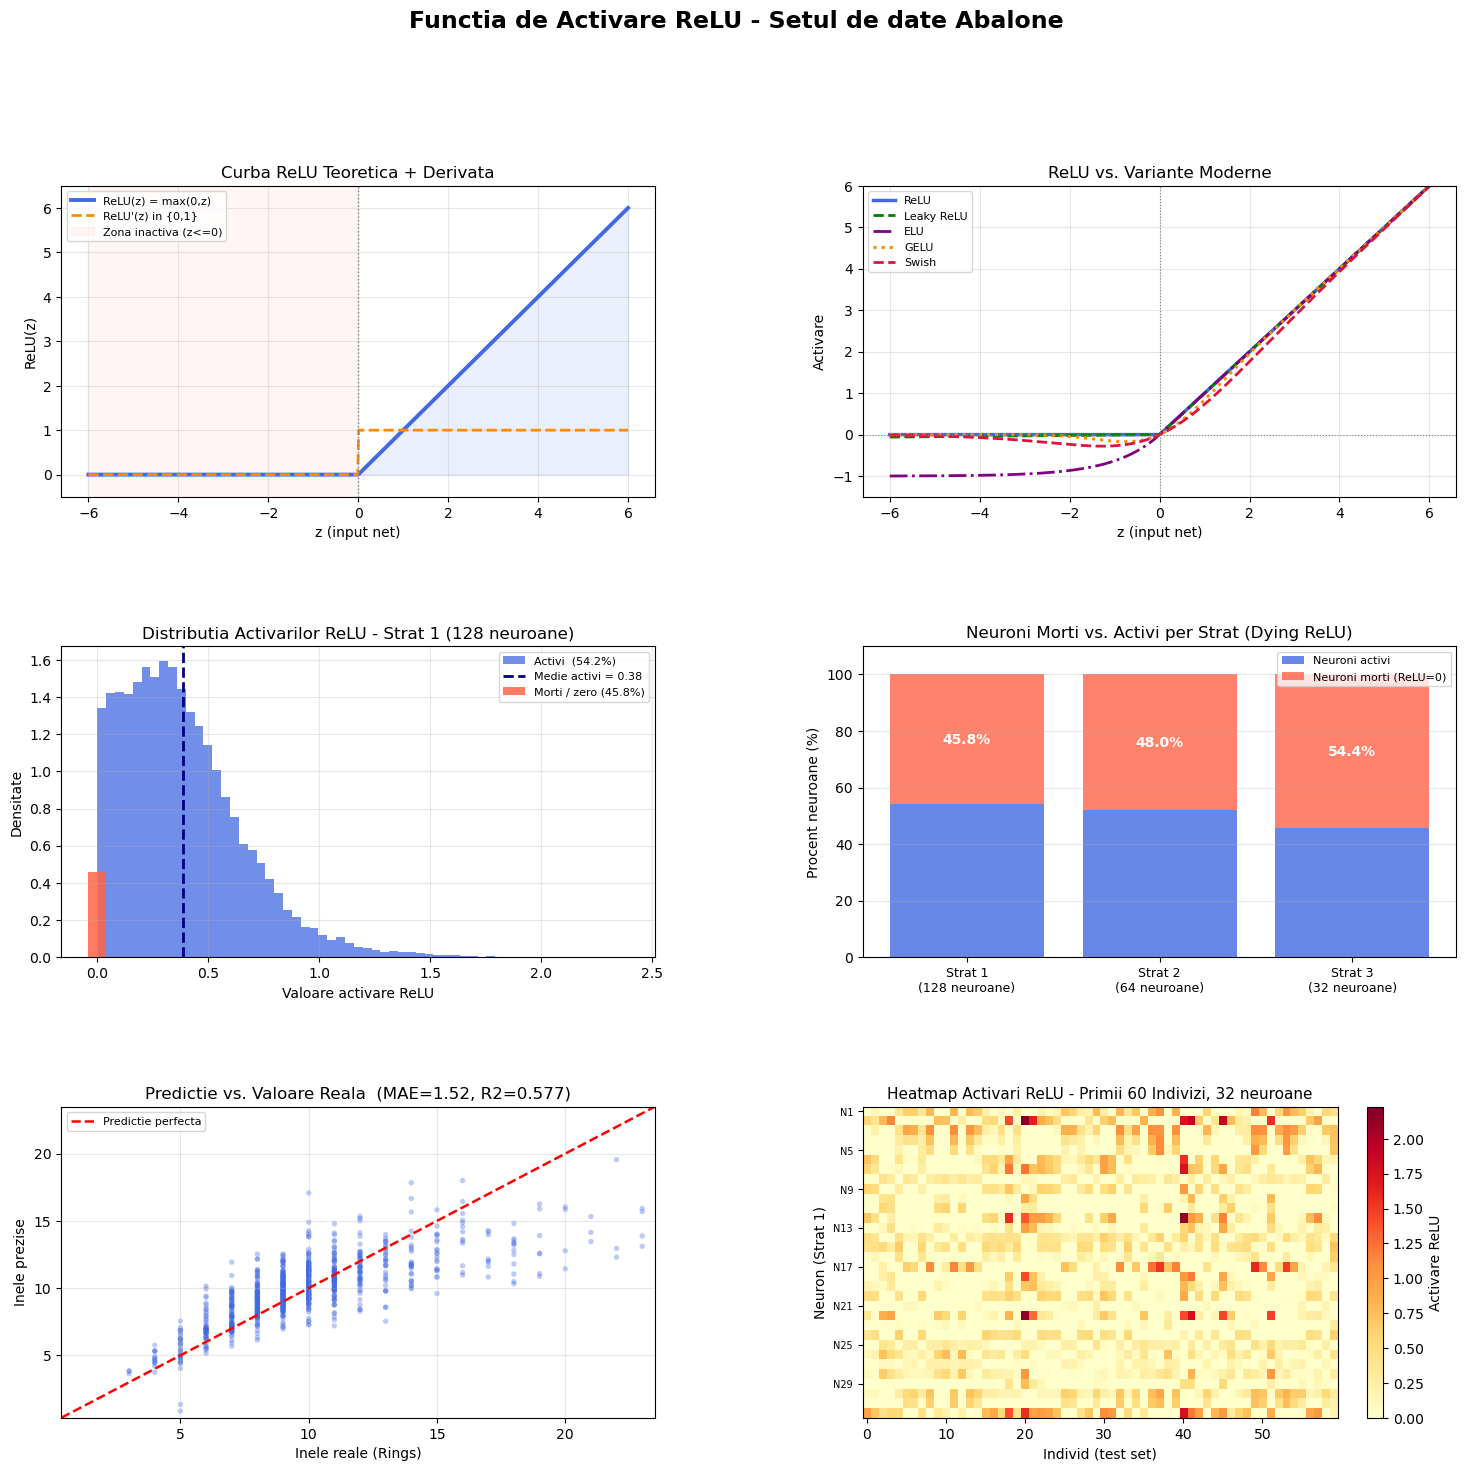

Graficul principal a fost salvat ca abalone_relu.png


In [6]:
# 6. VIZUALIZARE PRINCIPALA - 6 subgrafice
z_range = np.linspace(-6, 6, 600)

fig = plt.figure(figsize=(18, 16))
fig.suptitle('Functia de Activare ReLU - Setul de date Abalone',
             fontsize=17, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.35)

# (1,1) Curba ReLU teoretica + derivata
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(z_range, relu(z_range),       color='royalblue',  lw=2.8, label='ReLU(z) = max(0,z)')
ax1.plot(z_range, relu_deriv(z_range), color='darkorange', lw=2.0, ls='--', label="ReLU'(z) in {0,1}")
ax1.axvline(0, color='gray', ls=':', lw=1.0)
ax1.fill_between(z_range, relu(z_range), alpha=0.10, color='royalblue')
ax1.axvspan(-6, 0, alpha=0.06, color='tomato', label='Zona inactiva (z<=0)')
ax1.set_title('Curba ReLU Teoretica + Derivata', fontsize=12)
ax1.set_xlabel('z (input net)')
ax1.set_ylabel('ReLU(z)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.5, 6.5)

# (1,2) Comparatie ReLU vs variante
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(z_range, relu(z_range),        color='royalblue',  lw=2.5, ls='-',  label='ReLU')
ax2.plot(z_range, leaky_relu(z_range),  color='green',      lw=2.0, ls='--', label='Leaky ReLU')
ax2.plot(z_range, elu(z_range),         color='purple',     lw=2.0, ls='-.', label='ELU')
ax2.plot(z_range, gelu(z_range),        color='darkorange', lw=2.2, ls=':',  label='GELU')
ax2.plot(z_range, swish(z_range),       color='crimson',    lw=2.0, ls='--', label='Swish')
ax2.axhline(0, color='gray', ls=':', lw=0.8)
ax2.axvline(0, color='gray', ls=':', lw=0.8)
ax2.set_title('ReLU vs. Variante Moderne', fontsize=12)
ax2.set_xlabel('z (input net)')
ax2.set_ylabel('Activare')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-1.5, 6)

# (2,1) Distributia activarilor ReLU - Strat 1
ax3 = fig.add_subplot(gs[1, 0])
act1 = hidden_acts[0].flatten()
dead_pct = (act1 == 0).mean() * 100
active = act1[act1 > 0]
ax3.hist(active, bins=60, color='royalblue', alpha=0.75,
         label=f'Activi  ({100-dead_pct:.1f}%)', density=True)
ax3.bar(0, dead_pct / 100, width=0.08, color='tomato', alpha=0.85,
        label=f'Morti / zero ({dead_pct:.1f}%)')
if active.size > 0:
    ax3.axvline(active.mean(), color='navy', lw=2, ls='--',
                label=f'Medie activi = {active.mean():.2f}')
ax3.set_title('Distributia Activarilor ReLU - Strat 1 (128 neuroane)', fontsize=12)
ax3.set_xlabel('Valoare activare ReLU')
ax3.set_ylabel('Densitate')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# (2,2) Neuroni morti pe fiecare strat
ax4 = fig.add_subplot(gs[1, 1])
layer_names = [f'Strat {i+1}\n({a.shape[1]} neuroane)' for i, a in enumerate(hidden_acts)]
dead_pcts   = [(a == 0).mean() * 100 for a in hidden_acts]
active_pcts = [100 - d for d in dead_pcts]
x_pos = np.arange(len(layer_names))
bars_a = ax4.bar(x_pos, active_pcts, color='royalblue', alpha=0.80, label='Neuroni activi')
bars_d = ax4.bar(x_pos, dead_pcts, bottom=active_pcts,
                 color='tomato', alpha=0.80, label='Neuroni morti (ReLU=0)')
for bar, pct in zip(bars_d, dead_pcts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', ha='center', va='center', fontsize=10,
             fontweight='bold', color='white')
ax4.set_title('Neuroni Morti vs. Activi per Strat (Dying ReLU)', fontsize=12)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(layer_names, fontsize=9)
ax4.set_ylabel('Procent neuroane (%)')
ax4.set_ylim(0, 110)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

# (3,1) Valori prezise vs reale
ax5 = fig.add_subplot(gs[2, 0])
ax5.scatter(y_test, y_pred, alpha=0.35, s=15, color='royalblue', edgecolors='none')
lim = [min(y_test.min(), y_pred.min()) - 0.5,
       max(y_test.max(), y_pred.max()) + 0.5]
ax5.plot(lim, lim, 'r--', lw=1.8, label='Predictie perfecta')
ax5.set_title(f'Predictie vs. Valoare Reala  (MAE={mae:.2f}, R2={r2:.3f})', fontsize=12)
ax5.set_xlabel('Inele reale (Rings)')
ax5.set_ylabel('Inele prezise')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)
ax5.set_xlim(lim)
ax5.set_ylim(lim)

# (3,2) Heatmap activari ReLU
ax6 = fig.add_subplot(gs[2, 1])
n_show, n_neurons = 60, 32
heat_data = hidden_acts[0][:n_show, :n_neurons].T
im = ax6.imshow(heat_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax6, label='Activare ReLU')
ax6.set_title(f'Heatmap Activari ReLU - Primii {n_show} Indivizi, {n_neurons} neuroane', fontsize=11)
ax6.set_xlabel('Individ (test set)')
ax6.set_ylabel('Neuron (Strat 1)')
ax6.set_yticks(np.arange(0, n_neurons, 4))
ax6.set_yticklabels([f'N{i+1}' for i in range(0, n_neurons, 4)], fontsize=7)

plt.savefig('abalone_relu.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graficul principal a fost salvat ca abalone_relu.png')

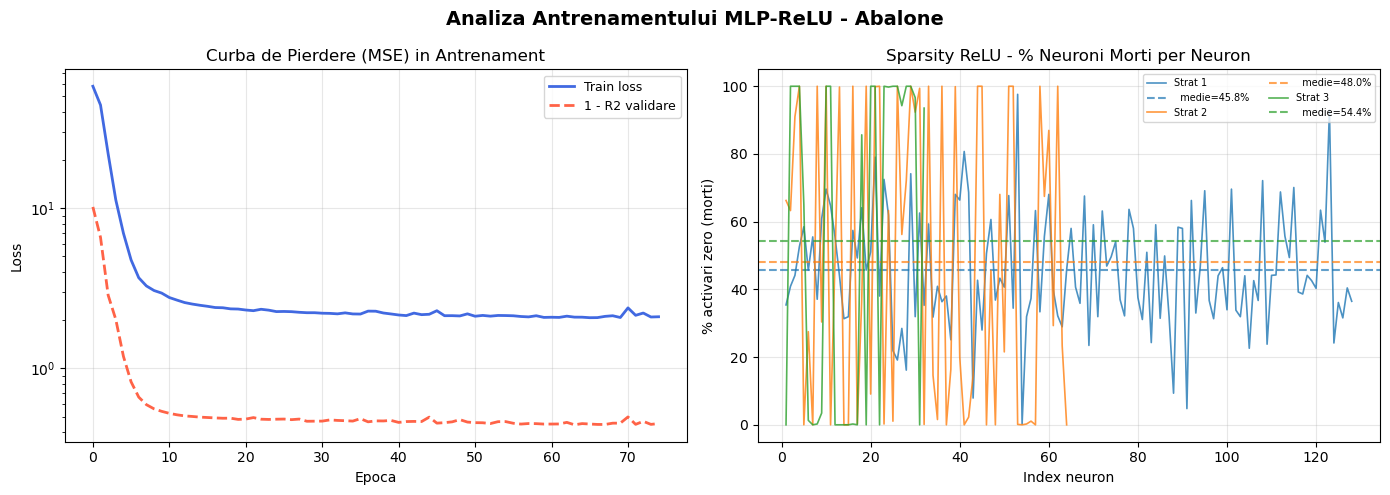

Graficul de antrenament a fost salvat ca abalone_relu_training.png


In [7]:
# 7. Curba de invatare + Sparsity per neuron
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Analiza Antrenamentului MLP-ReLU - Abalone', fontsize=14, fontweight='bold')

# Curba de pierdere
ax_loss = axes[0]
ax_loss.plot(mlp.loss_curve_, color='royalblue', lw=2, label='Train loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    val_sc = np.array(mlp.validation_scores_)
    ax_loss.plot(1 - val_sc, color='tomato', lw=2, ls='--', label='1 - R2 validare')
ax_loss.set_title('Curba de Pierdere (MSE) in Antrenament', fontsize=12)
ax_loss.set_xlabel('Epoca')
ax_loss.set_ylabel('Loss')
ax_loss.legend(fontsize=9)
ax_loss.grid(True, alpha=0.3)
ax_loss.set_yscale('log')

# Sparsity per neuron
ax_sp = axes[1]
colors_sp = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (act, col) in enumerate(zip(hidden_acts, colors_sp)):
    dead_per_neuron = (act == 0).mean(axis=0) * 100
    ax_sp.plot(range(1, act.shape[1]+1), dead_per_neuron,
               color=col, alpha=0.8, lw=1.2, label=f'Strat {i+1}')
    ax_sp.axhline(dead_per_neuron.mean(), color=col, ls='--', lw=1.5, alpha=0.7,
                  label=f'  medie={dead_per_neuron.mean():.1f}%')
ax_sp.set_title('Sparsity ReLU - % Neuroni Morti per Neuron', fontsize=12)
ax_sp.set_xlabel('Index neuron')
ax_sp.set_ylabel('% activari zero (morti)')
ax_sp.legend(fontsize=7, ncol=2)
ax_sp.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('abalone_relu_training.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graficul de antrenament a fost salvat ca abalone_relu_training.png')

## Interpretarea graficelor

| Grafic | Descriere |
|--------|-----------|
| **Curba ReLU + Derivata** | ReLU(z)=max(0,z): liniar pentru z>0, zero pentru z<=0. Derivata este o functie treapta {0,1}. |
| **ReLU vs. Variante** | Comparatie cu Leaky ReLU, ELU, GELU, Swish - solutii pentru neuroni morti. |
| **Distributia activarilor** | Histograma Strat 1: neuroni morti (zero) vs. activi (pozitivi). |
| **Neuroni morti per strat** | Stacked-bar cu % Dying ReLU pentru fiecare strat ascuns. |
| **Predictie vs. Reala** | Calitatea regresiei MLP-ReLU pe setul de test Abalone (MAE si R2). |
| **Heatmap activari** | Matrice neuron x individ - culorile intense = activari puternice. |
| **Curba de pierdere** | Evolutia MSE in antrenament (scara logaritmica). |
| **Sparsity per neuron** | Procentul de activari zero neuron cu neuron, pentru toate straturile. |

## Proprietati cheie ale ReLU

| Proprietate | Detaliu |
|-------------|----------|
| **Simplitate computationala** | Doar o comparatie cu zero - mult mai rapid decat sigmoid sau tanh |
| **Fara vanishing gradient** | Gradientul este 1 pentru z>0, semnalul se propaga fara atenuare |
| **Sparsity** | Multi neuroni cu activare 0 - reprezentari sparse, eficiente |
| **Dying ReLU** | Daca un neuron produce mereu z<=0, gradientul este mereu 0 - neuronul moare |
| **Solutii** | Leaky ReLU, ELU, GELU, Swish, batch normalization, learning rate mic |